In [1]:
import pandas as pd

ads = pd.read_csv("../Data/Social_Network_Ads.csv")

ads.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [2]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(ads[["Gender", "Age", "EstimatedSalary"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [3]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

In [5]:
knn.score(X_train_std, y_train)

0.925

In [6]:
knn.score(X_test_std, y_test)

0.875

In [7]:
len(y_test)

80

In [8]:
from sklearn.metrics import accuracy_score

print(f"Train Accuracy: {accuracy_score(y_train, knn.predict(X_train_std))}")
print(f"Test Accuracy: {accuracy_score(y_test, knn.predict(X_test_std))}")

Train Accuracy: 0.925
Test Accuracy: 0.875


In [9]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_train_std)

print(confusion_matrix(y_train, y_pred))

[[197  12]
 [ 12  99]]


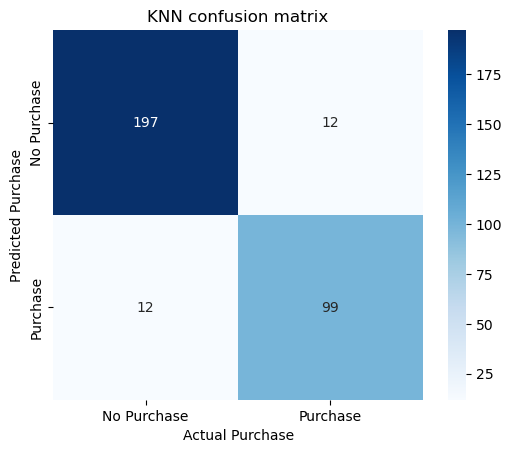

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

knn_confusion = confusion_matrix(y_train, knn.predict(X_train_std))
                                 
sns.heatmap(
    knn_confusion, 
    cmap="Blues",  
    annot=True, 
    fmt="g",
    square=True,
    xticklabels=["No Purchase", "Purchase"],        
    yticklabels=["No Purchase", "Purchase"]
).set(
    xlabel='Actual Purchase',
    ylabel='Predicted Purchase',
    title='KNN confusion matrix'
);

c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


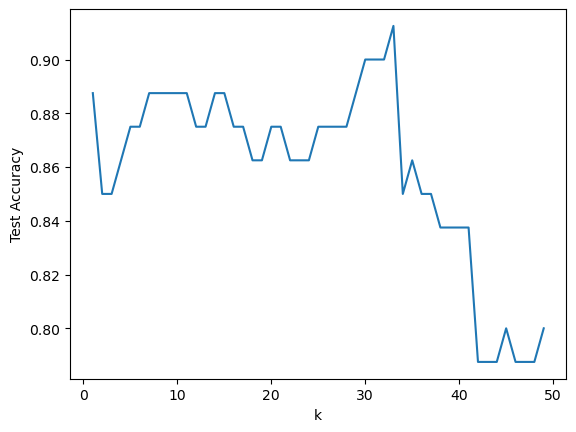

In [11]:
accuracy_scores = []

for k in range (1, 50):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_std, y_train)
    accuracy = accuracy_score(knn.predict(X_test_std), y_test)
    accuracy_scores.append(accuracy)
    
(sns.lineplot(
    x=range(1, 50),
    y=accuracy_scores)
 .set(
     xlabel="k", 
     ylabel="Test Accuracy")
);

In [12]:
from sklearn.model_selection import GridSearchCV

parameters = {"n_neighbors": range(1, 50)}

gridsearch = GridSearchCV(KNeighborsClassifier(), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'n_neighbors': 15}

In [13]:
k = 15
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_std, y_train)

accuracy_score(y_test, knn.predict(X_test_std))

0.8875

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

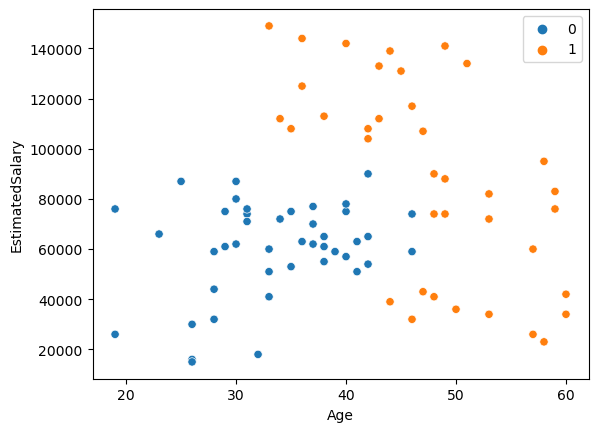

In [14]:
sns.scatterplot(data=X_test, x="Age", y="EstimatedSalary", hue=knn.predict(X_test_std))

In [15]:
import plotly.express as px

px.scatter_3d(X_test, x="Age", y="EstimatedSalary", z="Gender_Male", color=knn.predict(X_test_std))

In [16]:
knn.predict(X_test_std)[:5]

array([1, 1, 0, 0, 1], dtype=int64)

In [17]:
knn.predict_proba(X_test_std)[:5]

array([[0.06666667, 0.93333333],
       [0.46666667, 0.53333333],
       [0.73333333, 0.26666667],
       [1.        , 0.        ],
       [0.06666667, 0.93333333]])

In [18]:
knn.predict_proba(X_test_std)[1]

array([0.46666667, 0.53333333])

C:\Users\User\AppData\Local\Temp\ipykernel_16788\548573677.py:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Axes: xlabel='predicted_probability', ylabel='Event Rate'>

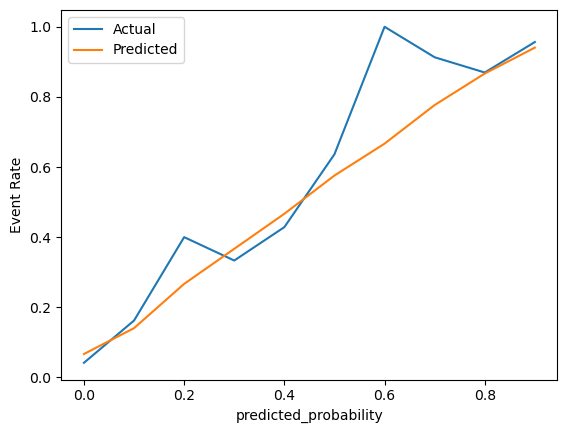

In [19]:
import numpy as np

bins = np.linspace(0, 1, 11)

# Create dataframe with Actual Classes & Predicted Probabilities
actual_vs_prob = (
    pd.DataFrame({
        "Actual": y_train,
        "Predicted": knn.predict_proba(X_train_std)[:, 1]})
)

# Create bins at increments of .1
actual_vs_prob["predicted_probability"] = (
    pd.cut(actual_vs_prob["Predicted"], 
    bins=bins,
    labels = bins[:-1].round(2))
)

# Group by probability bins and calculate actual even rate & plot
(actual_vs_prob
 .groupby("predicted_probability")
 .agg({"Actual": "mean", "Predicted": "mean"})
 .plot
 .line(ylabel="Event Rate")
)